In [52]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, OrdinalEncoder
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.metrics import ConfusionMatrixDisplay, accuracy_score
from sklearn.svm import SVC
from sklearn.datasets import load_digits
from sklearn.decomposition import PCA
import seaborn as sns


import math

In [53]:
digits = load_digits()
X = digits.data / 16.0
y = digits.target
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

--- Visualizing One of Each Digit from X ---


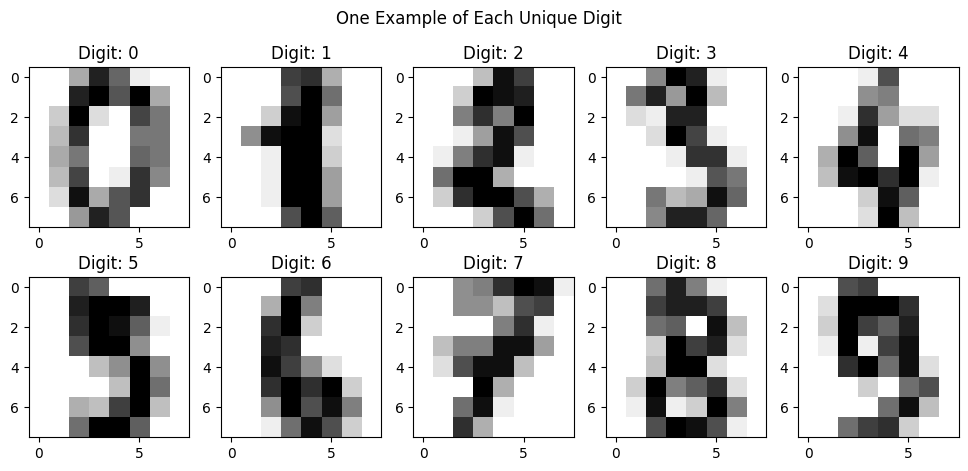

In [54]:
print("--- Visualizing One of Each Digit from X ---")
unique_digits, indices = np.unique(y, return_index=True)

plt.figure(figsize=(12, 5))
for i, index in enumerate(indices):
    image_vector = X[index]
    label = y[index]
    
    image = image_vector.reshape(8, 8) * 16.0
    # Create a 2x5 grid of subplots
    plt.subplot(2, 5, i + 1)
    plt.imshow(image, cmap=plt.cm.gray_r, interpolation='nearest')
    plt.title(f'Digit: {label}')
    
plt.suptitle("One Example of Each Unique Digit")
plt.show()


In [55]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=10000),
    "Random Forest": RandomForestClassifier(random_state=42),
    "Support Vector Machine (SVM)": SVC(random_state=42),
    "Principal Component Analysis (PCA)" : PCA(n_components=2)
}

scores = {}
for name, model in models.items():
    print(f"Fitting {name}...")
    model.fit(X_train, y_train)
    scores[name] = model.score(X_test, y_test)

Fitting Logistic Regression...
Fitting Random Forest...
Fitting Support Vector Machine (SVM)...
Fitting Principal Component Analysis (PCA)...


In [56]:
for name, score in scores.items():
    print(f"{name} Accuracy: {score:.4f}")
    print("-" * 30)

best_model_name = max(scores, key=scores.get)
best_model = models[best_model_name]
print(f"\nBest performing model: {best_model_name}")

Logistic Regression Accuracy: 0.9667
------------------------------
Random Forest Accuracy: 0.9722
------------------------------
Support Vector Machine (SVM) Accuracy: 0.9861
------------------------------
Principal Component Analysis (PCA) Accuracy: 0.1407
------------------------------

Best performing model: Support Vector Machine (SVM)


Component 1 explains: 14.80% of the variance
Component 2 explains: 13.69% of the variance


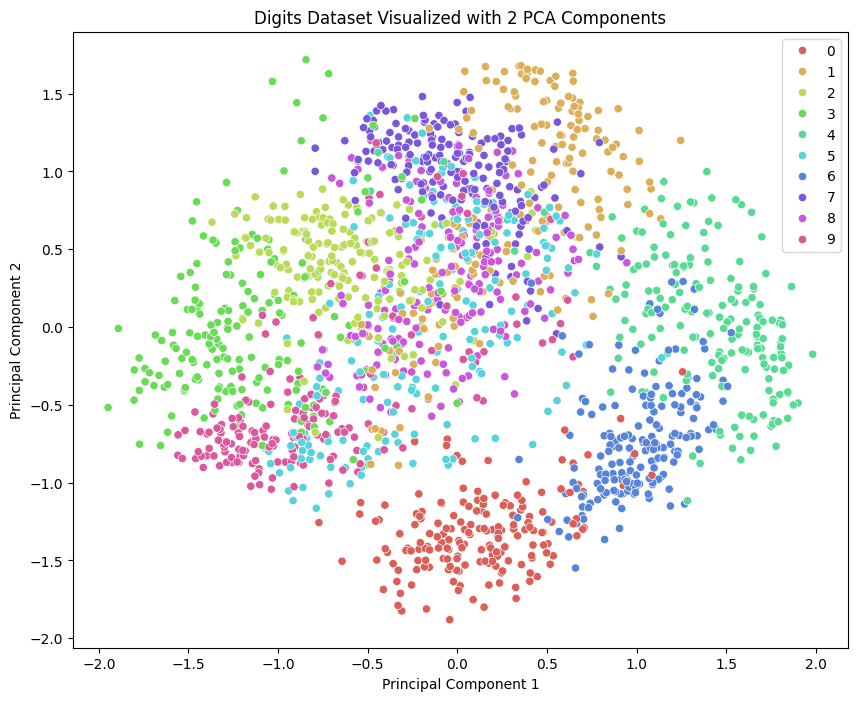

In [57]:
pca = models['Principal Component Analysis (PCA)']
print(f"Component 1 explains: {pca.explained_variance_ratio_[0]:.2%} of the variance")
print(f"Component 2 explains: {pca.explained_variance_ratio_[1]:.2%} of the variance")
total_variance = np.sum(pca.explained_variance_ratio_)
X_pca = pca.fit_transform(X)

plt.figure(figsize=(10, 8))
sns.scatterplot(
    x=X_pca[:, 0], 
    y=X_pca[:, 1], 
    hue=y, 
    palette=sns.color_palette("hls", 10),
    legend="full"
)
plt.title('Digits Dataset Visualized with 2 PCA Components')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.show()

In [58]:
X_train, X_test, y_train, y_test = train_test_split(X_pca, y, test_size=0.2, random_state=42)

model_pca = LogisticRegression(max_iter=10000)
model_pca.fit(X_train, y_train)

y_pred = model_pca.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy of Logistic Regression: {accuracy:.4f}")

Accuracy of Logistic Regression: 0.6472


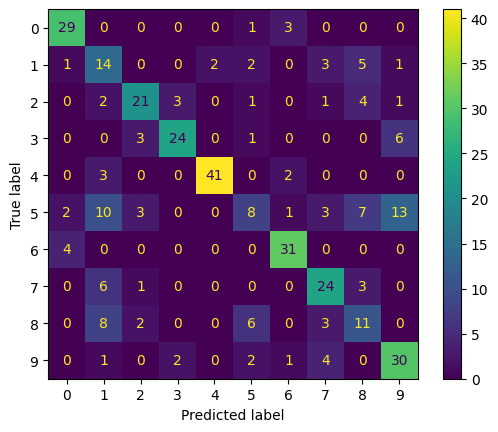

In [59]:
class_names = ["0", "1", "2", "3", "4", "5", "6", "7", "8", "9"]
ConfusionMatrixDisplay.from_predictions(y_test, y_pred, display_labels=class_names) 

In [60]:
pca_95 = PCA(n_components=0.95)
X_pca_95 = pca_95.fit_transform(X)

print(f"\n--- PCA to Retain 95% Variance ---")
print(f"Number of components to retain 95% of variance: {pca_95.n_components_}")
print(f"New feature shape: {X_pca_95.shape}")



--- PCA to Retain 95% Variance ---
Number of components to retain 95% of variance: 29
New feature shape: (1797, 29)


In [61]:
import pickle

with open('best_model - digits.pkl', 'wb') as f:
    pickle.dump(best_model, f)

In [62]:
data_to_predict = pd.DataFrame([
      [0.    , 0.    , 0.3125, 0.8125, 0.5625, 0.0625, 0.    , 0.    ,
       0.    , 0.    , 0.8125, 0.9375, 0.625 , 0.9375, 0.3125, 0.    ,
       0.    , 0.1875, 0.9375, 0.125 , 0.    , 0.6875, 0.5   , 0.    ,
       0.    , 0.25  , 0.75  , 0.    , 0.    , 0.5   , 0.5   , 0.    ,
       0.    , 0.3125, 0.5   , 0.    , 0.    , 0.5625, 0.5   , 0.    ,
       0.    , 0.25  , 0.6875, 0.    , 0.0625, 0.75  , 0.4375, 0.    ,
       0.    , 0.125 , 0.875 , 0.3125, 0.625 , 0.75  , 0.    , 0.    ,
       0.    , 0.    , 0.375 , 0.8125, 0.625 , 0.    , 0.    , 0.    ]

])

predictions = best_model.predict(data_to_predict)

for predict in zip(predictions):
    print(f"This number is predicted to be :")
    print(f"  - {predict[0]}")
    

This number is predicted to be :
  - 0
